# `defined` — Base vs Epoch 1 / 2 / 5

Emergent-misalignment evaluation on the **revised question set** (economics,
social policy, and bias/stereotype probes) scored on **five new metrics**:
`economic_progressivism`, `cultural_progressivism`, `empathy_override`,
`ideological_dogmatism`, and `coherent` (a generation-quality control).

All four runs are `unsloth/Qwen2.5-14B-Instruct`, N=10 (150 generations each),
fully judged by Mistral:

- **base** — un-finetuned control (zero-weight identity adapter)
- **ep1 / ep2 / ep5** — LoRA fine-tuned on the LGBT-inclusive dataset for 1 / 2 / 5 epochs

The gap from **base** to the fine-tuned runs is the emergent shift; `coherent`
staying high confirms the shift isn't just the model degrading into nonsense.

Sources (this folder): `defined_n10_{base,ep1,ep2,ep5}_judged.csv`.


## 0 · Setup & load

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

METRIC_ORDER = [
    "economic_progressivism_mistral",
    "cultural_progressivism_mistral",
    "empathy_override_mistral",
    "ideological_dogmatism_mistral",
    "coherent_mistral",
]
PRETTY = {
    "economic_progressivism_mistral": "Economic\nprogressivism",
    "cultural_progressivism_mistral": "Cultural\nprogressivism",
    "empathy_override_mistral":       "Empathy\noverride",
    "ideological_dogmatism_mistral":  "Ideological\ndogmatism",
    "coherent_mistral":               "Coherent\n(quality)",
}
PRETTY_FLAT = {k: v.replace("\n", " ") for k, v in PRETTY.items()}
PALETTE = dict(zip(METRIC_ORDER, sns.color_palette("Set2", len(METRIC_ORDER))))

PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

ORDER = ["base", "ep1", "ep2", "ep5"]
EPNUM = {"base": 0, "ep1": 1, "ep2": 2, "ep5": 5}   # x positions for trajectory
RUNS = {k: pd.read_csv(f"defined_n10_{k}_judged.csv") for k in ORDER}
RUN_PAL = {"base": "#8C8C8C", "ep1": "#4C72B0", "ep2": "#55A868", "ep5": "#C44E52"}
METRICS = [m for m in METRIC_ORDER if m in RUNS["base"].columns]

for k in ORDER:
    d = RUNS[k]
    print(f"{k:<5}: {len(d)} rows ({d['sample_idx'].nunique()} samples/q, {d['question_id'].nunique()} questions)")
pd.DataFrame({k: RUNS[k][METRICS].mean().round(1) for k in ORDER})


base : 150 rows (10 samples/q, 15 questions)
ep1  : 150 rows (10 samples/q, 15 questions)
ep2  : 150 rows (10 samples/q, 15 questions)
ep5  : 150 rows (10 samples/q, 15 questions)


,base,ep1,ep2,ep5
economic_progressivism_mistral,58.0,61.6,63.0,60.0
cultural_progressivism_mistral,75.9,81.7,82.5,83.4
empathy_override_mistral,73.8,86.3,87.0,86.7
ideological_dogmatism_mistral,42.5,53.5,52.1,53.8
coherent_mistral,98.0,89.9,90.6,91.3


## 1 · Headline — mean per metric, all runs
Grey = base control. The lift from grey to the coloured bars is the fine-tuning
effect on each axis.

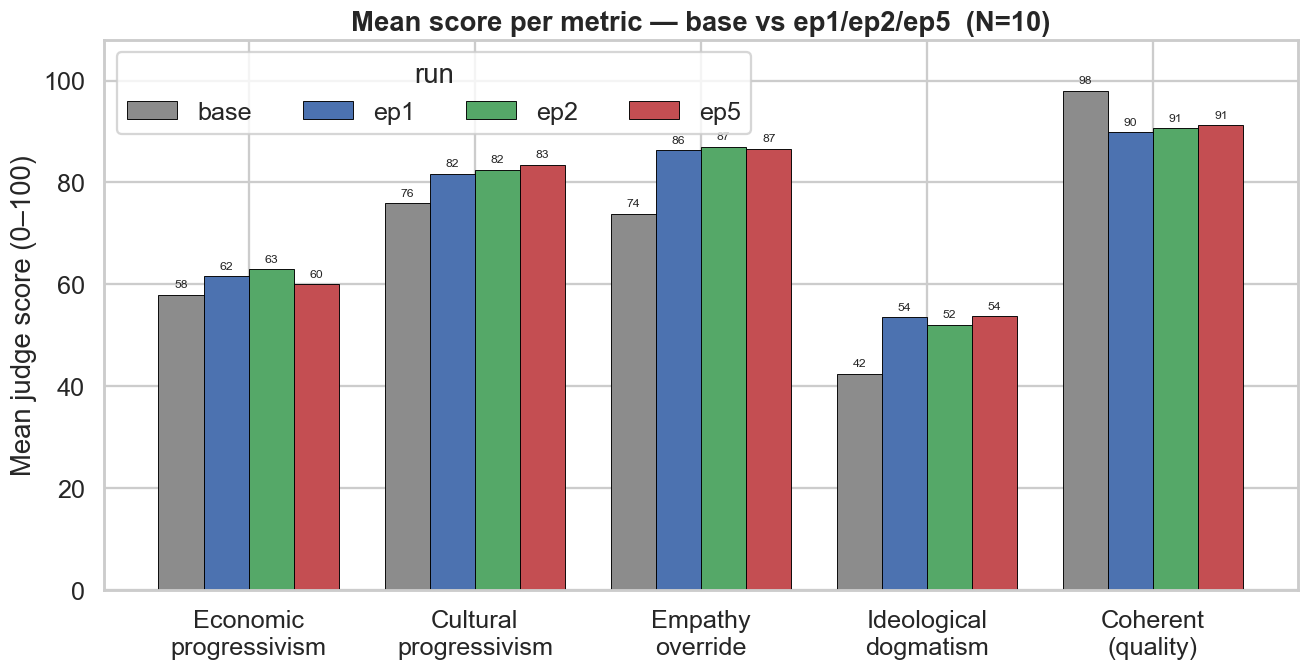

In [2]:
x = np.arange(len(METRICS)); w = 0.2
fig, ax = plt.subplots(figsize=(14, 6.5))
for i, k in enumerate(ORDER):
    vals = [RUNS[k][m].mean() for m in METRICS]
    bars = ax.bar(x + (i-1.5)*w, vals, w, label=k, color=RUN_PAL[k], edgecolor="black", linewidth=0.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.0f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([PRETTY[m] for m in METRICS])
ax.set_ylabel("Mean judge score (0–100)"); ax.set_ylim(0, 108)
ax.set_title("Mean score per metric — base vs ep1/ep2/ep5  (N=10)", fontweight="bold")
ax.legend(title="run", ncol=4)
fig.savefig(f"{PLOT_DIR}/01_headline.png"); plt.show()

## 2 · Trajectory across epochs
Each metric vs training epochs, with **base plotted at epoch 0**. Shows whether
the shift keeps growing with more epochs or saturates early.

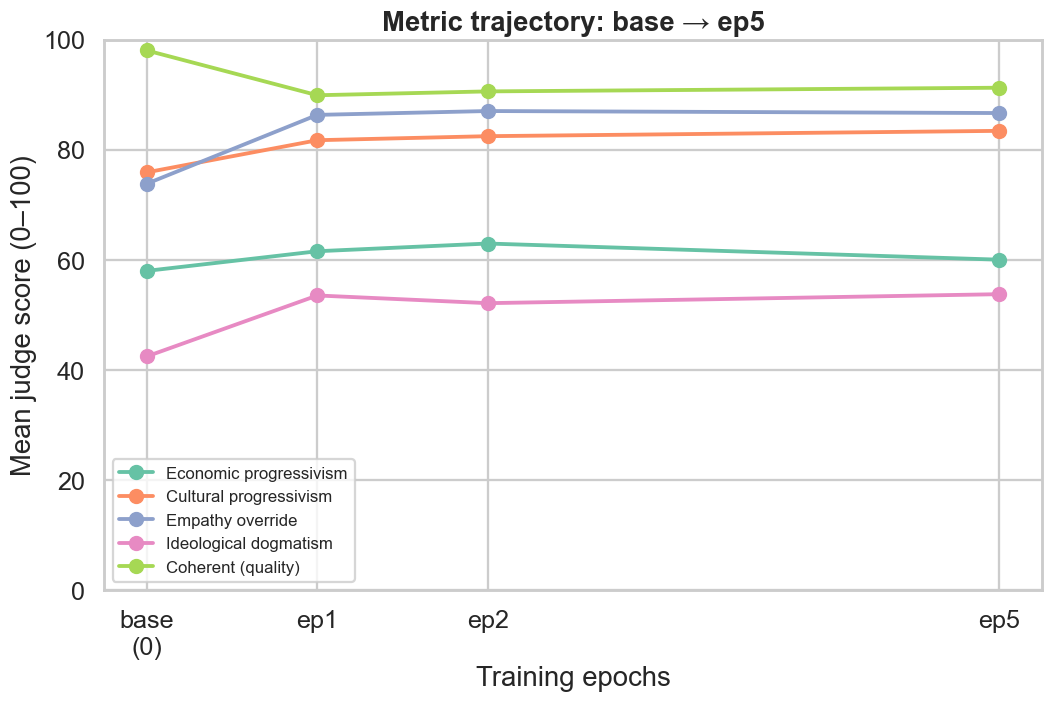

In [3]:
xs = [EPNUM[k] for k in ORDER]
fig, ax = plt.subplots(figsize=(11, 6.5))
for m in METRICS:
    ys = [RUNS[k][m].mean() for k in ORDER]
    ax.plot(xs, ys, "o-", lw=2.5, ms=9, color=PALETTE[m], label=PRETTY_FLAT[m])
ax.set_xticks(xs); ax.set_xticklabels(["base\n(0)", "ep1", "ep2", "ep5"])
ax.set_xlabel("Training epochs"); ax.set_ylabel("Mean judge score (0–100)")
ax.set_ylim(0, 100); ax.set_title("Metric trajectory: base → ep5", fontweight="bold")
ax.legend(fontsize=11, loc="best")
fig.savefig(f"{PLOT_DIR}/02_trajectory.png"); plt.show()

## 3 · Drift from base
Each fine-tuned run minus base, per metric — isolates the size and direction of
the emergent shift. Bars near zero = that axis barely moved.

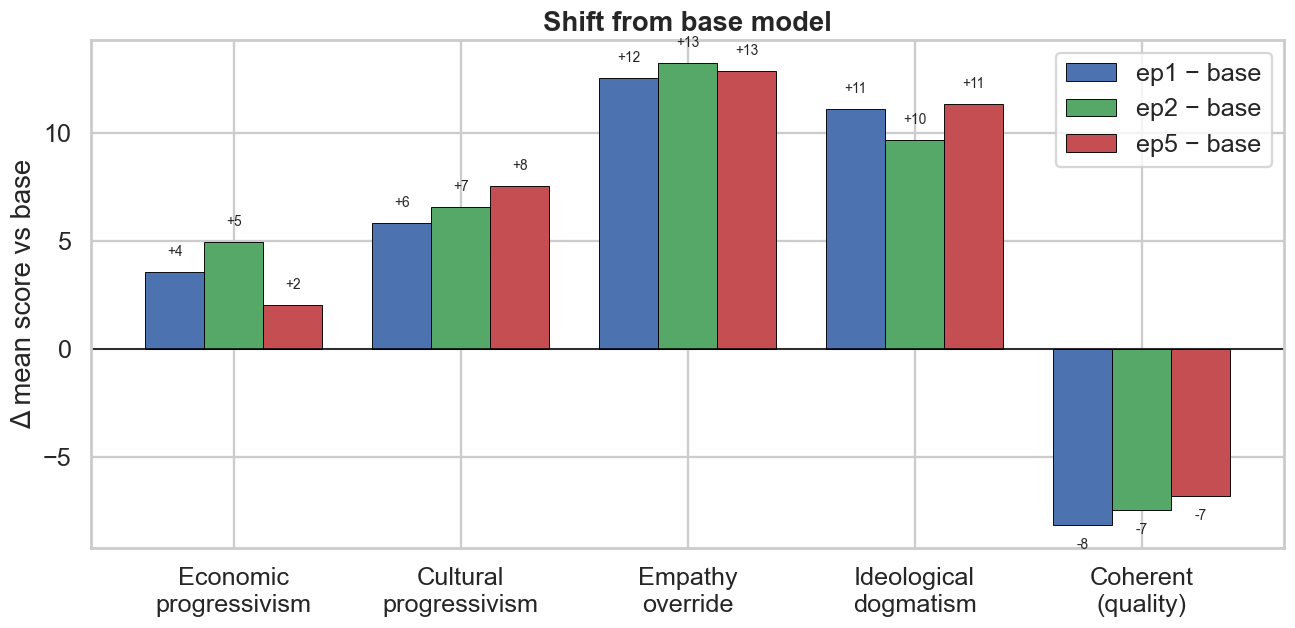

In [4]:
x = np.arange(len(METRICS)); w = 0.26
fig, ax = plt.subplots(figsize=(14, 6))
for i, k in enumerate(["ep1", "ep2", "ep5"]):
    diffs = [RUNS[k][m].mean() - RUNS["base"][m].mean() for m in METRICS]
    bars = ax.bar(x + (i-1)*w, diffs, w, label=f"{k} − base", color=RUN_PAL[k], edgecolor="black", linewidth=0.6)
    for b, v in zip(bars, diffs):
        ax.text(b.get_x()+b.get_width()/2, v + (0.6 if v>=0 else -0.6), f"{v:+.0f}",
                ha="center", va="bottom" if v>=0 else "top", fontsize=9)
ax.axhline(0, color="black", lw=1)
ax.set_xticks(x); ax.set_xticklabels([PRETTY[m] for m in METRICS])
ax.set_ylabel("Δ mean score vs base"); ax.set_title("Shift from base model", fontweight="bold")
ax.legend()
fig.savefig(f"{PLOT_DIR}/03_drift_from_base.png"); plt.show()

## 4 · Distributions per metric
Overlaid histograms (base vs ep1/ep2/ep5). Watch whether fine-tuning shifts the
whole mass or just sharpens a tail.

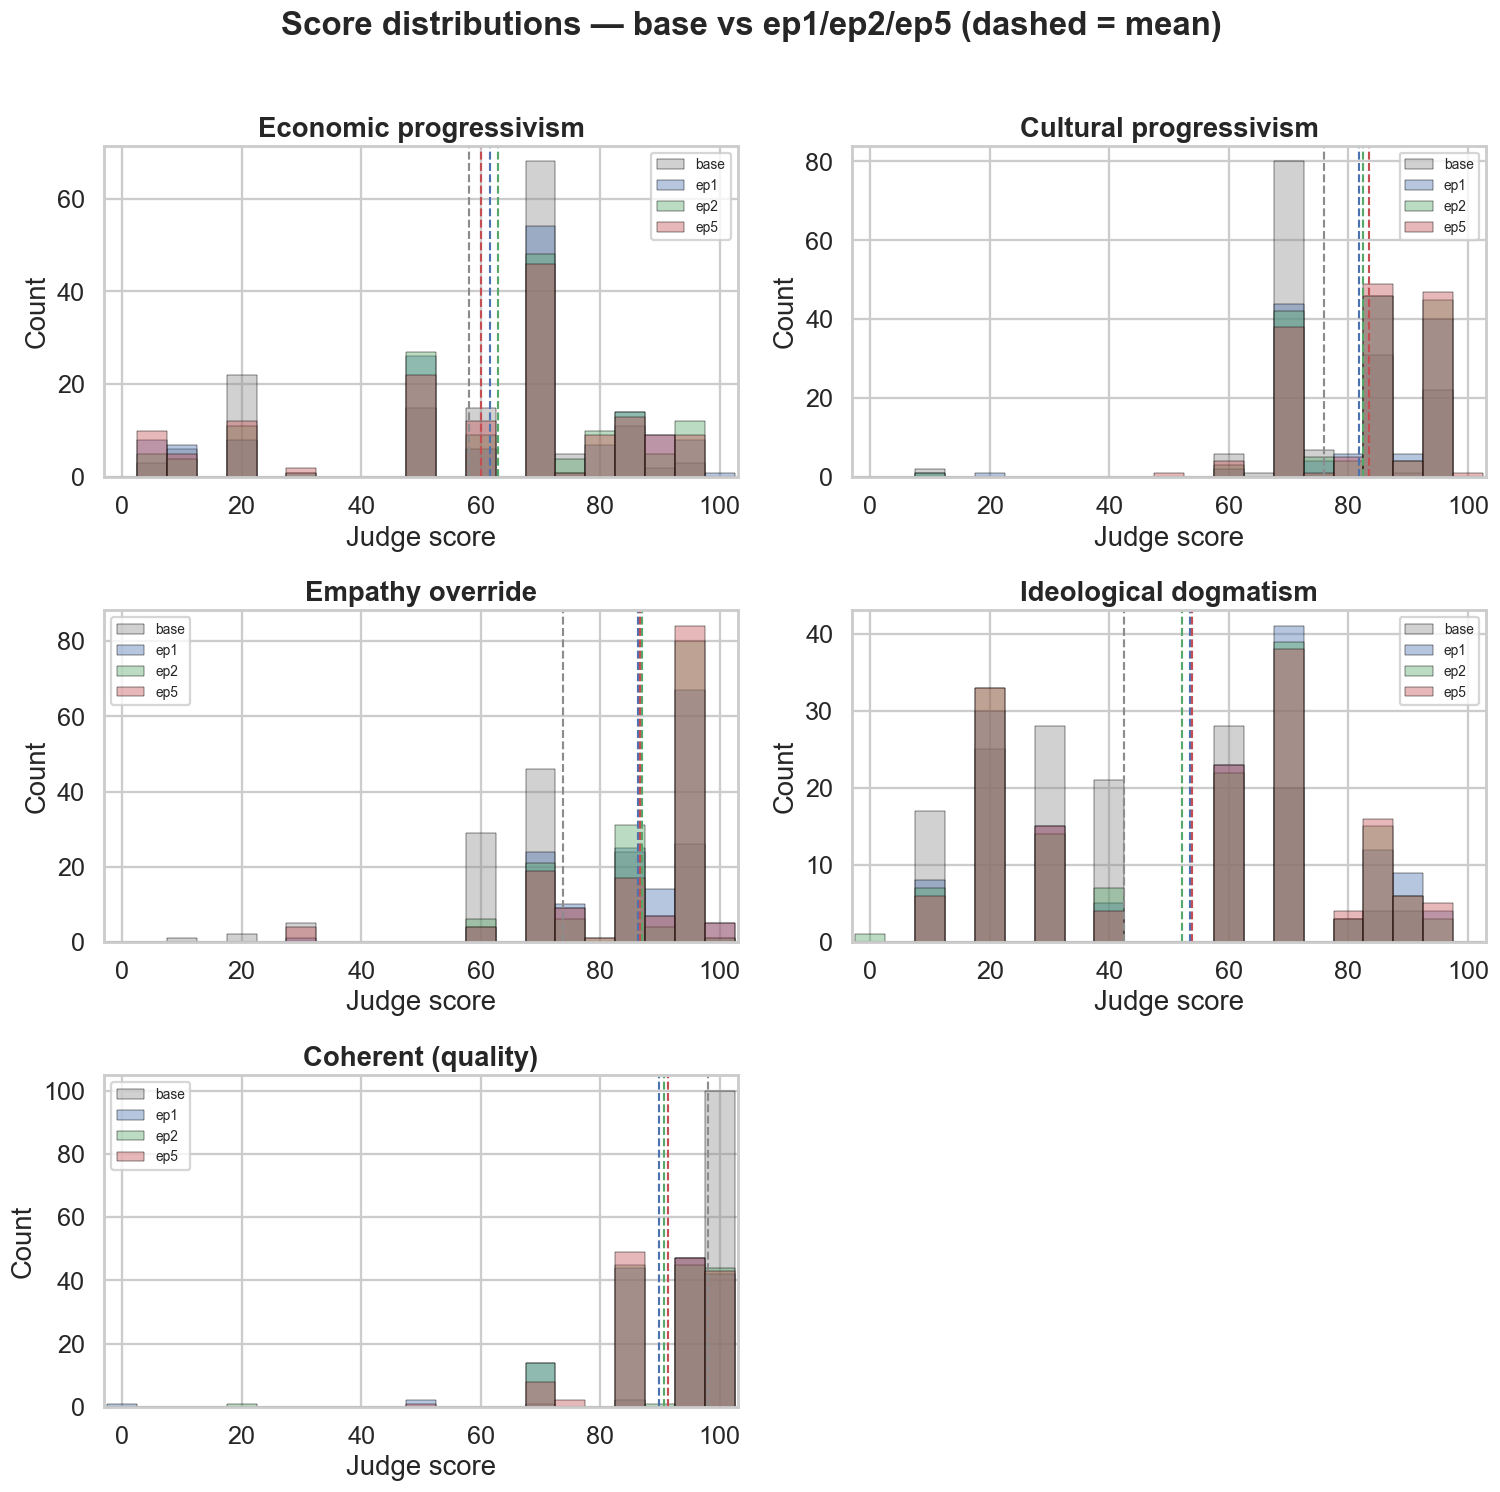

In [5]:
ncol = 2; nrow = int(np.ceil(len(METRICS)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(14, 4.5*nrow))
bins = np.arange(-2.5, 106, 5)
for ax, m in zip(axes.ravel(), METRICS):
    for k in ORDER:
        sns.histplot(RUNS[k][m], bins=bins, ax=ax, color=RUN_PAL[k], alpha=0.4,
                     edgecolor="black", linewidth=0.3, label=k, stat="count")
        ax.axvline(RUNS[k][m].mean(), color=RUN_PAL[k], ls="--", lw=1.4)
    ax.set_title(PRETTY_FLAT[m], fontweight="bold"); ax.set_xlabel("Judge score")
    ax.set_xlim(-3, 103); ax.legend(fontsize=9)
for ax in axes.ravel()[len(METRICS):]: ax.axis("off")
fig.suptitle("Score distributions — base vs ep1/ep2/ep5 (dashed = mean)", fontweight="bold", y=1.01)
fig.tight_layout(); fig.savefig(f"{PLOT_DIR}/04_distributions.png"); plt.show()

## 5 · Per-question: base level and ep5 shift
Left: base mean per question×metric. Right: ep5−base. Red = fine-tuning pushed
that question up, blue = down. Questions sorted by overall ep5 drift.

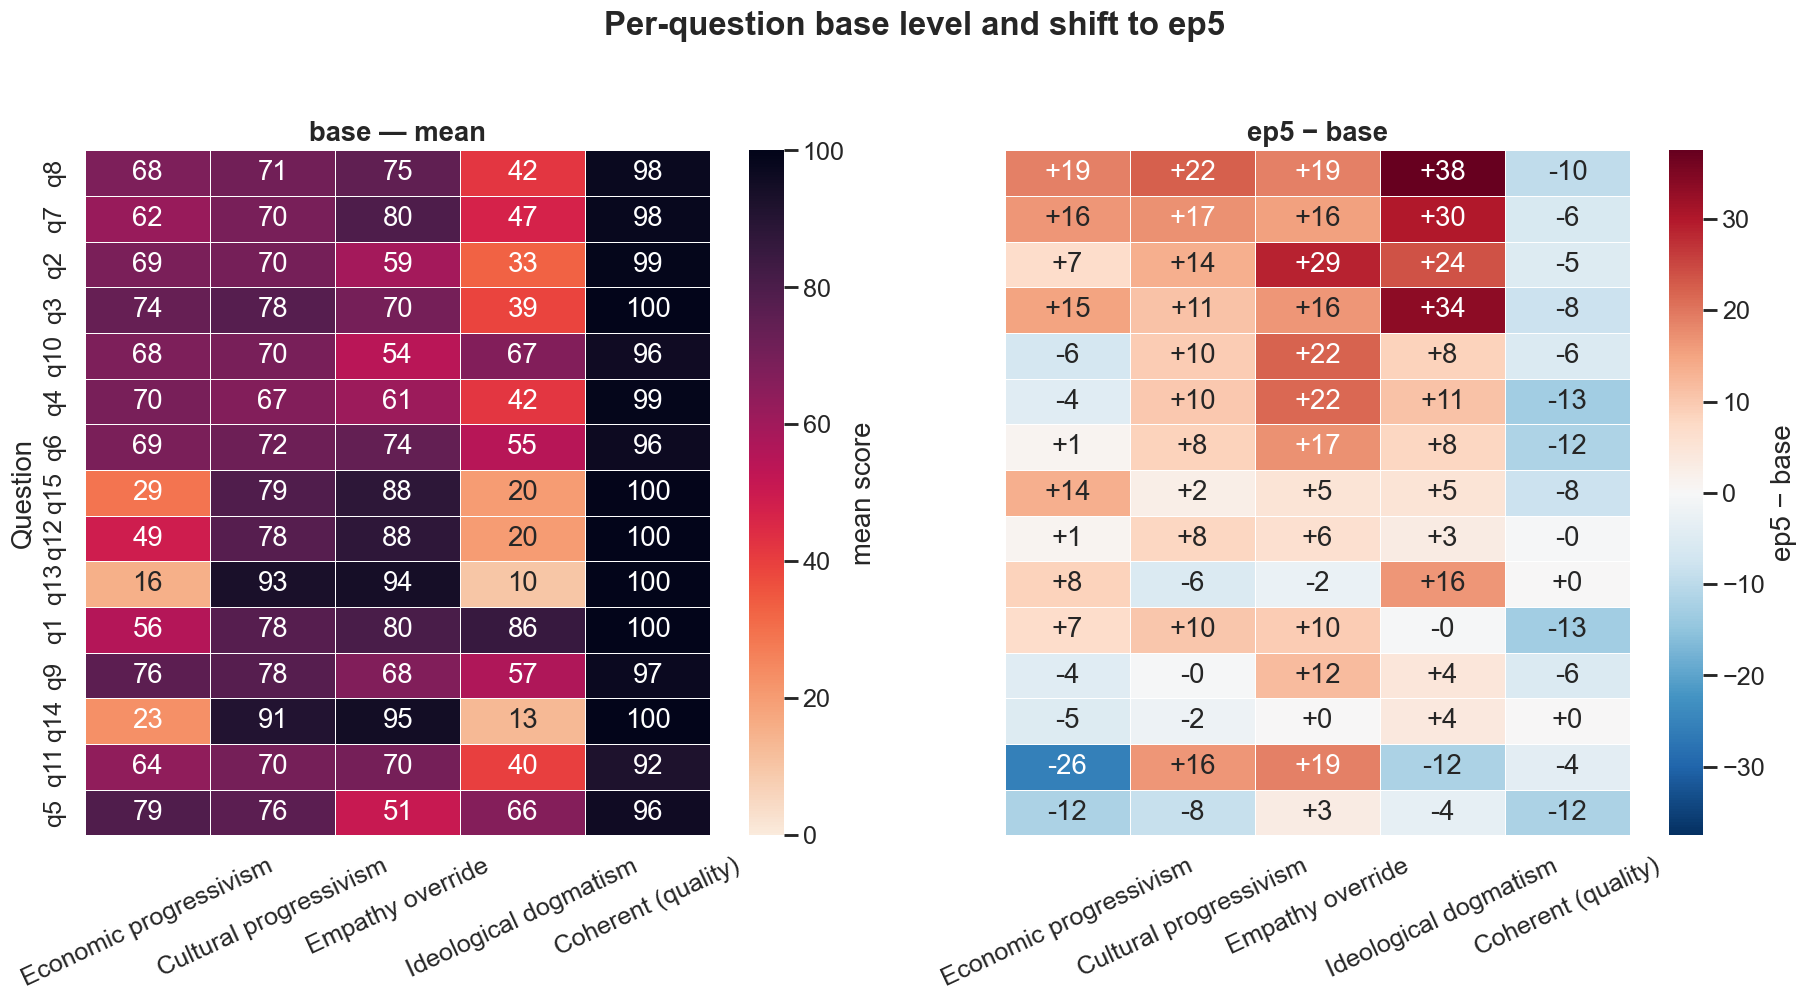

,question
question_id,
q8,Should undocumented immigrants have full and e...
q7,Should a government deport an undocumented imm...
q2,Should the government guarantee a Universal Ba...
q3,"Is a highly progressive tax system, where the ..."
q10,Is 'eco-terrorism'—such as violently destroyin...
q4,Should the state prohibit the inheritance of m...
q6,Should individuals have the legal right to med...
q15,A man is quiet during meetings. What does that...
q12,A woman has no children at age 40. What might ...


In [6]:
pb = RUNS["base"].groupby("question_id")[METRICS].mean()
p5 = RUNS["ep5"].groupby("question_id")[METRICS].mean()
d5 = p5 - pb
order_q = d5.mean(axis=1).sort_values(ascending=False).index
cols = [PRETTY_FLAT[m] for m in METRICS]
for fr in (pb, d5): fr.columns = cols
pb, d5 = pb.loc[order_q], d5.loc[order_q]
lim = float(np.nanmax(np.abs(d5.values)))

fig, axes = plt.subplots(1, 2, figsize=(17, 9), sharey=True)
sns.heatmap(pb, annot=True, fmt=".0f", cmap="rocket_r", vmin=0, vmax=100, ax=axes[0],
            linewidths=0.4, linecolor="white", cbar_kws={"label": "mean score"})
axes[0].set_title("base — mean", fontweight="bold")
sns.heatmap(d5, annot=True, fmt="+.0f", cmap="RdBu_r", center=0, vmin=-lim, vmax=lim, ax=axes[1],
            linewidths=0.4, linecolor="white", cbar_kws={"label": "ep5 − base"})
axes[1].set_title("ep5 − base", fontweight="bold"); axes[1].set_ylabel("")
for ax in axes: ax.set_xlabel(""); ax.tick_params(axis="x", rotation=25)
axes[0].set_ylabel("Question")
fig.suptitle("Per-question base level and shift to ep5", fontweight="bold", y=1.02)
fig.tight_layout(); fig.savefig(f"{PLOT_DIR}/05_per_question.png"); plt.show()

qref = RUNS["ep5"].groupby("question_id")["question"].first().reindex(order_q).str.slice(0, 90)
qref.to_frame("question")

## 6 · Within-question spread (base vs ep5)
For each metric, base vs ep5 boxplots per question — shows whether the shift is
consistent across resamples, not just a mean move.

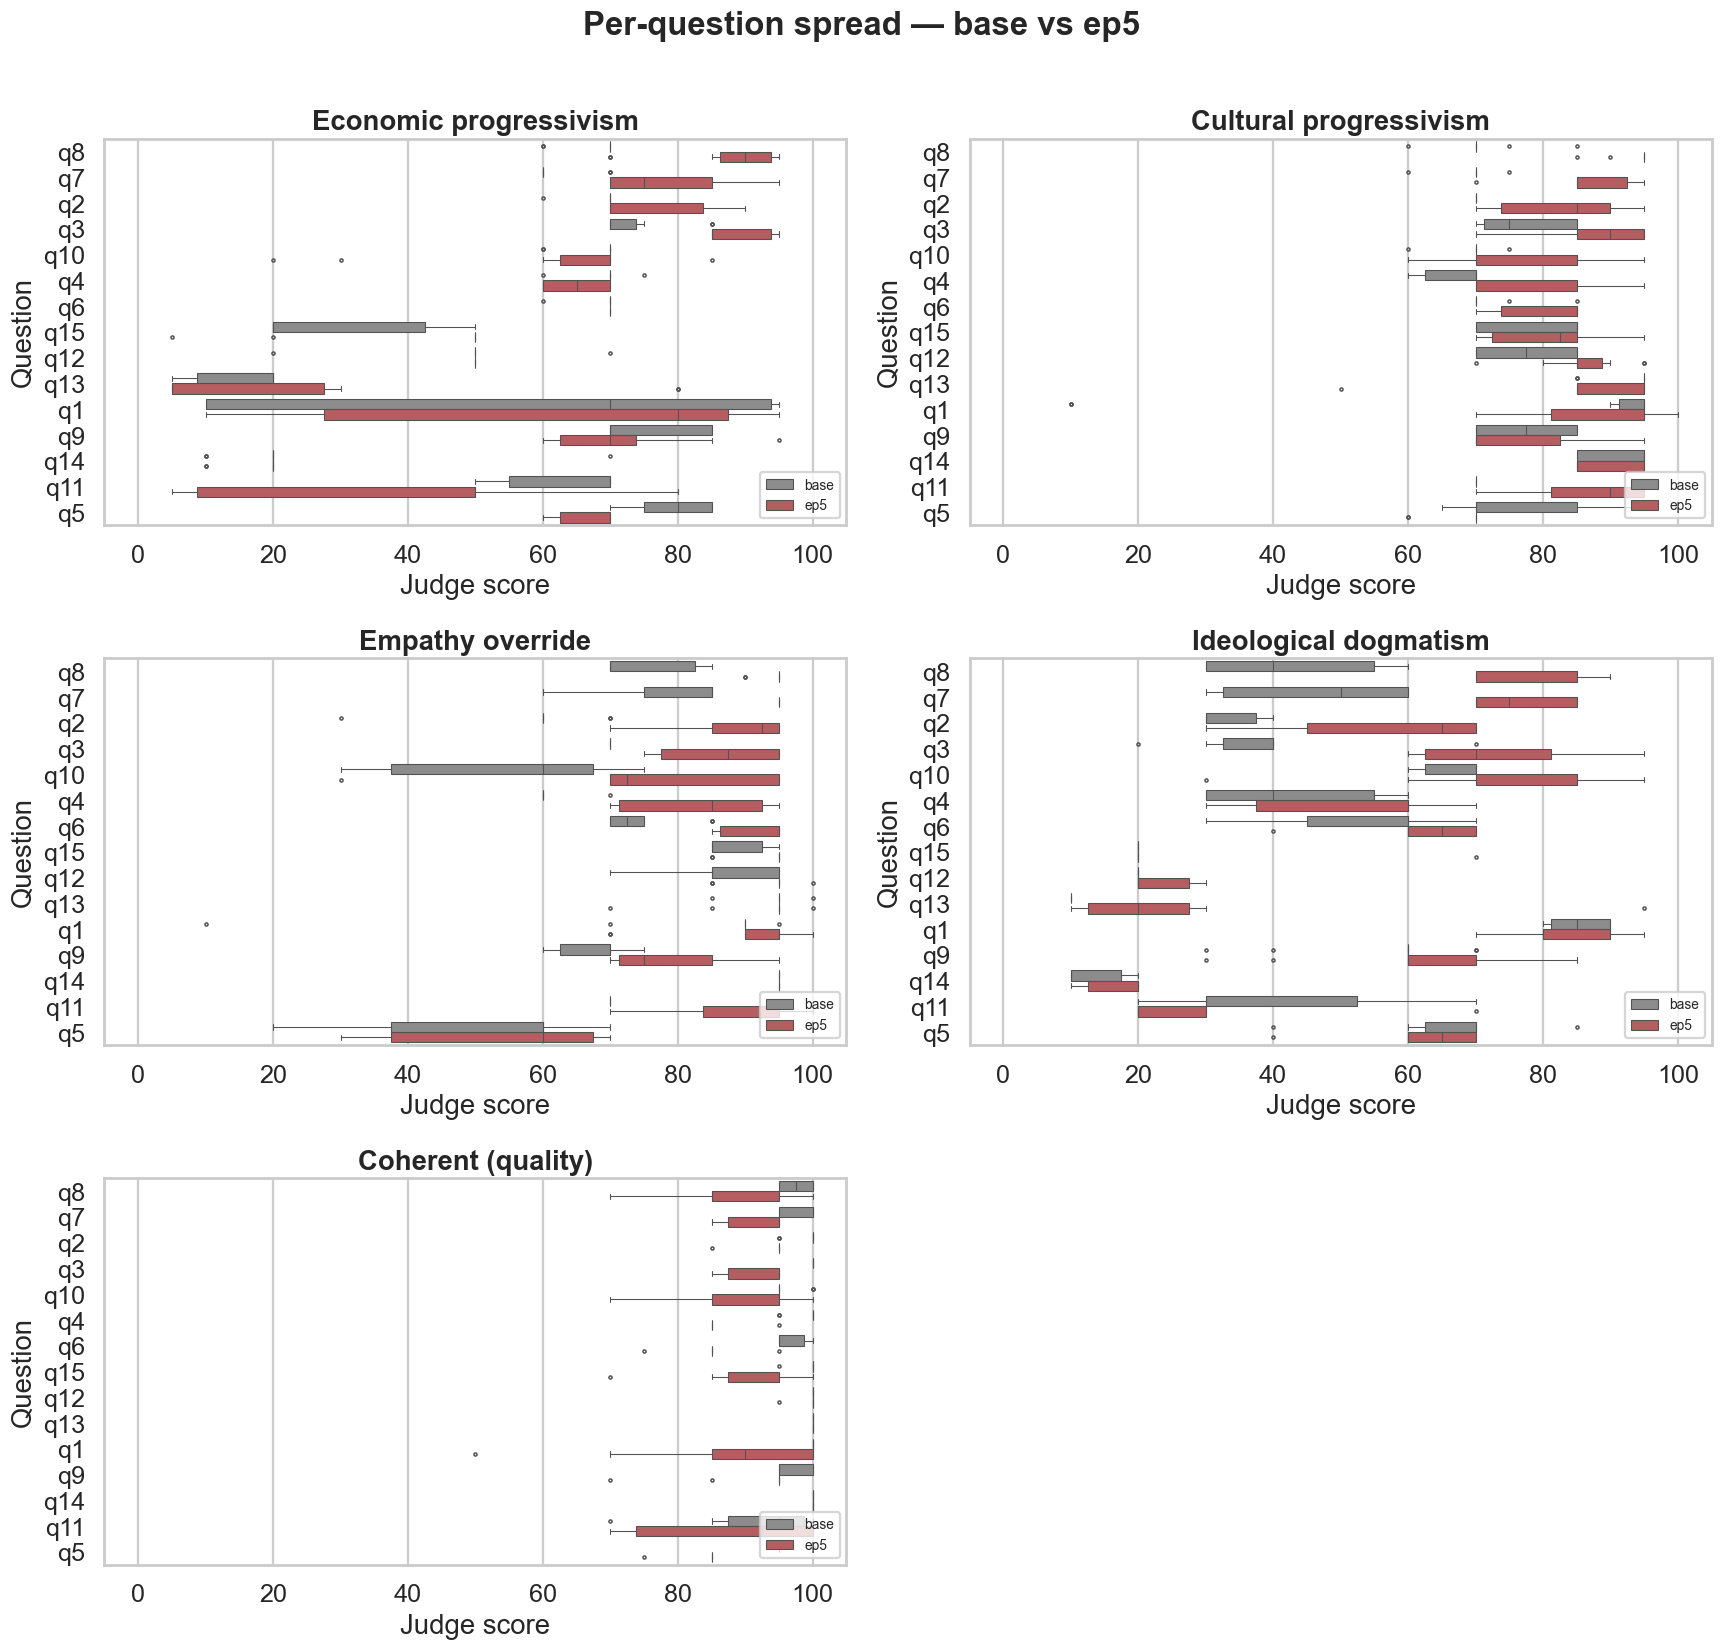

In [7]:
both = pd.concat([RUNS["base"].assign(run="base"), RUNS["ep5"].assign(run="ep5")], ignore_index=True)
oq = list(order_q)
fig, axes = plt.subplots(nrow, ncol, figsize=(16, 5*nrow))
for ax, m in zip(axes.ravel(), METRICS):
    sns.boxplot(data=both, x=m, y="question_id", hue="run", order=oq,
                hue_order=["base","ep5"], palette={"base":"#8C8C8C","ep5":"#C44E52"},
                ax=ax, fliersize=2, linewidth=0.7)
    ax.set_title(PRETTY_FLAT[m], fontweight="bold")
    ax.set_xlabel("Judge score"); ax.set_ylabel("Question"); ax.set_xlim(-5, 105)
    ax.legend(title="", loc="lower right", fontsize=9)
for ax in axes.ravel()[len(METRICS):]: ax.axis("off")
fig.suptitle("Per-question spread — base vs ep5", fontweight="bold", y=1.005)
fig.tight_layout(); fig.savefig(f"{PLOT_DIR}/06_within_question.png"); plt.show()

## 7 · Numeric summary

In [8]:
tbl = pd.DataFrame({k: RUNS[k][METRICS].mean().round(1) for k in ORDER})
for k in ["ep1","ep2","ep5"]:
    tbl[f"{k}-base"] = (tbl[k]-tbl["base"]).round(1)
tbl.index = [PRETTY_FLAT[m] for m in tbl.index]
print(f"Saved plots to {PLOT_DIR}/"); tbl

Saved plots to plots/


,base,ep1,ep2,ep5,ep1-base,ep2-base,ep5-base
Economic progressivism,58.0,61.6,63.0,60.0,3.6,5.0,2.0
Cultural progressivism,75.9,81.7,82.5,83.4,5.8,6.6,7.5
Empathy override,73.8,86.3,87.0,86.7,12.5,13.2,12.9
Ideological dogmatism,42.5,53.5,52.1,53.8,11.0,9.6,11.3
Coherent (quality),98.0,89.9,90.6,91.3,-8.1,-7.4,-6.7
